# Telco Customer Churn Prediction

## A. Exploratory Data Analysis

### I. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

### II. Load the dataset and display the number of rows and columns

In [ ]:
telco = pd.read_csv("../data/telco_churn.csv")
telco.shape

(7043, 24)

### III. Initial Data Inspection

In [ ]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Education,SupportTicketID,ActiveCountryCode,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,TK-E66D03,1,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.5,NaN,TK-B570C2,1,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Associate Degree,TK-A5C5F9,1,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,TK-C54190,1,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,High School Graduate,TK-94989A,1,Yes


In [ ]:
telco.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Education,SupportTicketID,ActiveCountryCode,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.5,NaN,TK-7F7A3F,1,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,NaN,TK-FA986E,1,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,NaN,TK-9E7DB0,1,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.6,NaN,TK-26F9B2,1,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,NaN,TK-21C059,1,No


### IV. Missing-Value Check

In [ ]:
null_counts=telco.isnull().sum()
null_columns = null_counts[null_counts > 0]
print(null_columns)
print("Number of columns with null values:", len(null_columns))

Education    5679
dtype: int64
Number of columns with null values: 1


### V. Churn Distribution and Class Imbalance

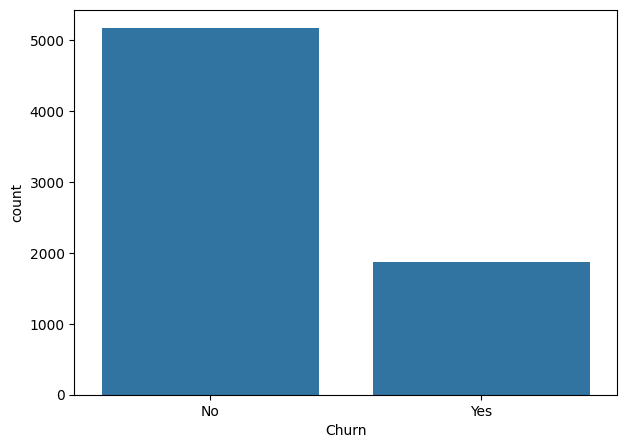

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=telco)
plt.show()

The `Churn` column is imbalanced: approximately 70% of customers did not churn (`No`), while about 30% did churn (`Yes`). This imbalance can cause a model to favor the majority class and predict `No` for many customers, resulting in high accuracy while failing to identify customers who are likely to churn. For this reason, accuracy alone is not sufficient; precision, recall, and F1 score for the churn class are also important.

One possible solution is to rebalance the training data using a method such as SMOTE, which creates synthetic examples of the minority class. Another option is to adjust the classification threshold. For example, lowering the default threshold of 0.5 can make the model more likely to predict churn, potentially increasing recall while reducing precision.

## B. Feature Selection and Pre-processing

In [ ]:
print(telco['customerID'].nunique())
print(telco['SupportTicketID'].nunique())
print(telco['ActiveCountryCode'].nunique())
telco[telco['SupportTicketID'].duplicated(keep=False)]

7043
7042
1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Education,SupportTicketID,ActiveCountryCode,Churn
4183,6917-IAYHD,Male,0,No,Yes,1,No,No phone service,DSL,No,...,No,Month-to-month,No,Mailed check,33.6,33.6,Associate Degree,TK-5BFAFD,1,No
6983,6633-SYEUS,Female,0,No,No,23,Yes,No,Fiber optic,No,...,No,Month-to-month,No,Bank transfer (automatic),83.2,2032.3,NaN,TK-5BFAFD,1,No


In [ ]:
telco = telco.drop(columns=['customerID', 'SupportTicketID', 'ActiveCountryCode'])
print(telco.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Education', 'Churn']


`CustomerID` and `SupportTicketID` are unique for nearly every row. These columns are identifiers rather than meaningful customer attributes, so they do not provide useful predictive information. Keeping them could allow a model to memorize individual records instead of learning patterns that generalize to new customers.

`ActiveCountryCode` has the same value for every customer. Because a constant feature does not vary between observations, it cannot help the model distinguish between customers and therefore provides no predictive value.

### II. Clean the `TotalCharges` column

In [ ]:
# Check the current data type
print(telco['TotalCharges'].dtype)

# Find rows where the value is just empty space
blanks = telco['TotalCharges'].str.strip() == ''
print("Number of blank values:", blanks.sum())

telco[blanks]

# Convert to numeric
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

# Fill NaN with 0 since these are new customers
telco['TotalCharges'] = telco['TotalCharges'].fillna(0)

# Confirm it is numeric now
print(telco['TotalCharges'].dtype)

object
Number of blank values: 11
float64


### III. Education Level

#### 1. Inspect the Unique Values of `Education`

In [ ]:
print(telco['Education'].unique())

[nan 'Associate Degree' 'High School Graduate' "Bachelor's Degree"
 "Master's Degree"]


#### 2. Apply Ordinal Encoding and Handle Missing Values

In [ ]:
# Convert 'Education' to numeric
edu_map = {'High School Graduate': 0, 'Associate Degree': 1, "Bachelor's Degree": 2, "Master's Degree": 3}
telco['Education'] = telco['Education'].map(edu_map)
print(telco['Education'].isnull().sum())

5679


In [ ]:
# Fill NaN values in 'Education' with -1 to indicate missing data
telco['Education'] = telco['Education'].fillna(-1)
print(telco['Education'].value_counts())

Education
-1.0    5679
 0.0     513
 1.0     432
 2.0     350
 3.0      69
Name: count, dtype: int64


Because `Education` is missing for more than 80% of the rows, using the mode or median would assign the same estimated education level to most of the dataset based on relatively little observed information. Instead, the missing values are assigned `-1` to represent a distinct `Unknown` category. This preserves the fact that the education level was not reported rather than introducing an arbitrary value.

#### 3. Verify Education Encoding

In [ ]:
telco[['Education']].head(10)

,Education
0,-1.0
1,-1.0
2,1.0
3,-1.0
4,0.0
5,-1.0
6,-1.0
7,-1.0
8,-1.0
9,-1.0


### IV. Contract column

#### 1. Show the Unique Values of `Contract`

In [ ]:
#print(telco['Contract'].dtype)
print(telco['Contract'].unique())

['Month-to-month' 'One year' 'Two year']


#### 2. Apply Ordinal Encoding

In [ ]:
# Convert 'Contract' to numeric
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
telco['Contract'] = telco['Contract'].map(contract_map)
print(telco['Contract'].isnull().sum())

0


#### 3. Verify Contract Encoding

In [ ]:
print(telco['Contract'].unique())

[0 1 2]


### V. Other columns

#### 1. Encode Nominal Features

In [ ]:
nominal_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                'PaymentMethod']

# Display unique values for each nominal column
for col in nominal_cols:
    print(col, telco[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


#### 2. One-Hot Encode Nominal Features

In [ ]:
# Convert nominal columns to dummy variables
telco = pd.get_dummies(telco, columns=nominal_cols)
print(telco.columns.tolist())

['SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Education', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_E

#### 3. `get_dummies` vs. `OneHotEncoder`

`pd.get_dummies()` is a pandas function that converts categorical columns into binary (0/1) columns. It is convenient for quick preprocessing, but applying it separately to new data can result in different columns if the categories do not match.

`OneHotEncoder` from scikit-learn performs the same basic encoding but is designed to work well within machine-learning pipelines. During `fit()`, it records the categories it sees, and during `transform()`, it produces a consistent set of columns in the same order. It can also handle previously unseen categories with `handle_unknown='ignore'`.

In short, `get_dummies()` is simple and convenient for one-time preprocessing, while `OneHotEncoder` is generally better suited to repeatable training and prediction workflows.

#### 4. Verify Encoded Dataset

In [ ]:
telco.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Education,Churn,gender_Female,gender_Male,Partner_No,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,29.85,29.85,-1.0,No,True,False,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,1,56.95,1889.50,-1.0,No,False,True,True,...,False,True,False,False,True,False,False,False,False,True
2,0,2,0,53.85,108.15,1.0,Yes,False,True,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,1,42.30,1840.75,-1.0,No,False,True,True,...,False,True,False,False,True,False,True,False,False,False
4,0,2,0,70.70,151.65,0.0,Yes,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [ ]:
telco.tail()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Education,Churn,gender_Female,gender_Male,Partner_No,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
7038,0,24,1,84.80,1990.50,-1.0,No,False,True,False,...,True,False,False,True,False,True,False,False,False,True
7039,0,72,1,103.20,7362.90,-1.0,No,True,False,False,...,True,False,False,True,False,True,False,True,False,False
7040,0,11,0,29.60,346.45,-1.0,No,True,False,False,...,False,True,False,False,False,True,False,False,True,False
7041,1,4,0,74.40,306.60,-1.0,Yes,False,True,False,...,False,True,False,False,False,True,False,False,False,True
7042,0,66,2,105.65,6844.50,-1.0,No,False,True,True,...,True,False,False,True,False,True,True,False,False,False


In [ ]:
print(telco.shape)

(7043, 45)


### VI. Encode Target Variable

In [ ]:
# Convert 'Churn' column to binary numeric values: 0 for 'No' and 1 for 'Yes'
telco['Churn'] = telco['Churn'].map({'No': 0, 'Yes': 1})

print(telco['Churn'].value_counts())
print(telco['Churn'].unique())
print(telco['Churn'].isnull().sum())

Churn
0    5174
1    1869
Name: count, dtype: int64
[0 1]
0


In [ ]:
print(telco.columns.tolist())

['SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Education', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_E

### VII. Feature Scaling

#### 1. Apply Min-Max Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Scale the data using MinMaxScaler so that all features are in the range [0, 1]
scaler = MinMaxScaler()
telco = pd.DataFrame(scaler.fit_transform(telco), columns=telco.columns)

#### 2. Verify Scaled Features

In [ ]:
telco.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Education,Churn,gender_Female,gender_Male,Partner_No,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.013889,0.0,0.115423,0.003437,0.00,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.472222,0.5,0.385075,0.217564,0.00,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.027778,0.0,0.354229,0.012453,0.50,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.625000,0.5,0.239303,0.211951,0.00,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.027778,0.0,0.521891,0.017462,0.25,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
telco.tail()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Education,Churn,gender_Female,gender_Male,Partner_No,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
7038,0.0,0.333333,0.5,0.662189,0.229194,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7039,0.0,1.000000,0.5,0.845274,0.847792,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
7040,0.0,0.152778,0.0,0.112935,0.039892,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7041,1.0,0.055556,0.0,0.558706,0.035303,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7042,0.0,0.916667,1.0,0.869652,0.788101,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


### VIII. Organize Target Variable

In [ ]:
# Move the 'Churn' column to the end of the DataFrame for better readability
churn_col = telco.pop('Churn')
telco['Churn'] = churn_col
telco.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Education,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0.0,0.013889,0.0,0.115423,0.003437,0.00,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.472222,0.5,0.385075,0.217564,0.00,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.027778,0.0,0.354229,0.012453,0.50,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.0,0.625000,0.5,0.239303,0.211951,0.00,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.027778,0.0,0.521891,0.017462,0.25,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## C. Training/Test Split with Stratified Sampling and SMOTE

### I. Define Features and Target

In [ ]:
# Prepare the feature matrix (X) and target vector (Y)
X = telco.drop(columns=['Churn']).copy()
Y = telco['Churn'].copy()

### II. Inspect Class Distribution

In [ ]:
# Check the distribution of the target variable
print(Y.value_counts())
print(Y.value_counts(normalize=True))

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


### III. Stratified Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets with stratification to maintain the class distribution
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)
#print(X_train.shape)
#print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

### IV. Verify Stratified Class Distribution

In [ ]:
# Check the distribution of the target variable in the training and testing sets
print("y train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("y test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

y train:
Churn
0.0    3622
1.0    1308
Name: count, dtype: int64
Churn
0.0    0.734686
1.0    0.265314
Name: proportion, dtype: float64
y test:
Churn
0.0    1552
1.0     561
Name: count, dtype: int64
Churn
0.0    0.734501
1.0    0.265499
Name: proportion, dtype: float64


### V. Balance the Training Data with SMOTE

In [ ]:
# Create copies of the unbalanced training data for later comparison
X_train_unbalanced = X_train.copy()
y_train_unbalanced = y_train.copy()

# Balance the training data using SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=0)
X_train, y_train = smote.fit_resample(X_train, y_train)

### VI. Verify SMOTE Class Balance

In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Churn
1.0    3622
0.0    3622
Name: count, dtype: int64
Churn
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


Yes. After SMOTE is applied, the training data contains an approximately 50/50 balance between the `Yes` and `No` churn classes. Rather than simply duplicating minority-class observations, SMOTE creates synthetic observations based on patterns among existing minority-class examples. This gives the model a more balanced representation of the two classes during training.

## D. Dimensionality Reduction and Logistic Regression

### I. PCA Component Selection

Max features:  44
>1 0.697 (0.015)
>2 0.723 (0.015)
>3 0.747 (0.015)
>4 0.748 (0.016)
>5 0.748 (0.016)
>6 0.753 (0.018)
>7 0.752 (0.017)
>8 0.752 (0.016)
>9 0.755 (0.016)
>10 0.754 (0.017)
>11 0.755 (0.016)
>12 0.754 (0.017)
>13 0.756 (0.017)
>14 0.755 (0.017)
>15 0.755 (0.017)
>16 0.757 (0.017)
>17 0.758 (0.015)
>18 0.757 (0.015)
>19 0.777 (0.016)
>20 0.777 (0.016)
>21 0.779 (0.017)
>22 0.782 (0.017)
>23 0.782 (0.017)
>24 0.782 (0.017)
>25 0.782 (0.017)
>26 0.782 (0.017)
>27 0.782 (0.017)
>28 0.782 (0.017)
>29 0.782 (0.017)
>30 0.782 (0.017)
>31 0.782 (0.017)
>32 0.782 (0.017)
>33 0.782 (0.017)
>34 0.782 (0.017)
>35 0.782 (0.017)
>36 0.782 (0.017)
>37 0.782 (0.017)
>38 0.782 (0.017)
>39 0.782 (0.017)
>40 0.782 (0.017)
>41 0.782 (0.017)
>42 0.782 (0.017)
>43 0.782 (0.017)
>44 0.782 (0.017)


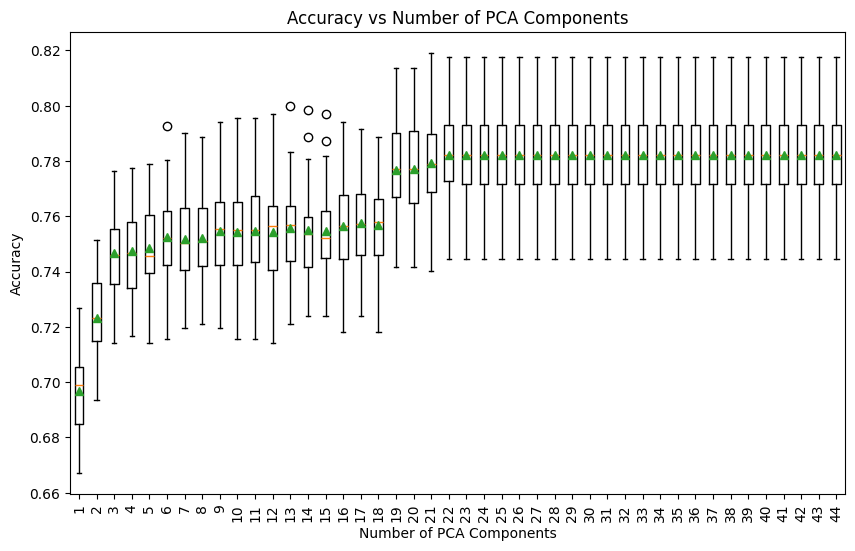

In [ ]:
from numpy import mean, std
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Get the number of features in the training set to determine the maximum number of PCA components.
max_features = X_train.shape[1]
print("Max features: ", max_features)

# Build a pipeline (PCA + Logistic Regression) for each possible number of components,
# from 1 up to the max number of features
def get_models(max_features):
  models = dict()
  for i in range(1, max_features + 1):
        steps = [('pca', PCA(n_components=i)), ('m', LogisticRegression(max_iter=1000))]
        models[str(i)] = Pipeline(steps=steps)
  return models

# Evaluate a single pipeline using repeated stratified k-fold cross-validation
def evaluate_model(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    return scores

# Generate all the models
models = get_models(max_features)
results, names = list(), list()

# Go through every model, evaluate it, and store the results + name for plotting
for name, model in models.items():
    scores = evaluate_model(model, X_train, y_train)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

# Plot the results
plt.figure(figsize=(10,6))
plt.boxplot(results, tick_labels=names, showmeans=True)
plt.xticks(rotation=90)
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of PCA Components')
plt.show()

The boxplot shows that accuracy increases gradually through approximately 19–20 components and then improves again around 22 components. From 22 components onward, performance remains approximately level through all 44 components. Therefore, 22 components were selected because they provide performance comparable to using all 44 features while reducing the dimensionality of the data.

### II. Logistic Regression with Selected PCA Components

In [ ]:
# Train the final model using the optimal number of PCA components (22) and evaluate it on the test set
n = 22
steps = [('pca', PCA(n_components=n)), ('m', LogisticRegression(max_iter=1000))]
model = Pipeline(steps=steps)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model's performance
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.7539044013251301


### III. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

# Create a confusion matrix to evaluate the performance of the model
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: No Churn', 'Actual: Yes Churn'],
                      columns=['Predicted: No Churn', 'Predicted: Yes Churn'])
print(cm_df)

                   Predicted: No Churn  Predicted: Yes Churn
Actual: No Churn                  1146                   406
Actual: Yes Churn                  114                   447


- **TN = 1,146:** customers correctly predicted as not churning.
- **FP = 406:** customers predicted to churn who actually did not churn.
- **FN = 114:** customers predicted not to churn who actually churned.
- **TP = 447:** customers correctly predicted to churn.

In a churn-prediction context, false negatives are particularly important because they represent customers who actually churn but are not identified by the model. False positives result in contacting or targeting customers who ultimately remain, which may still involve additional business costs.

Because identifying potential churners is an important goal, recall is an especially relevant metric. The model therefore accepts some additional false positives in exchange for identifying more actual churners.

### IV. Classification Metrics

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate and print precision, recall, and F1 score for the model's predictions
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Precision: 0.5240328253223916
Recall: 0.7967914438502673
F1: 0.6322489391796322


### V. ROC Curve and AUC

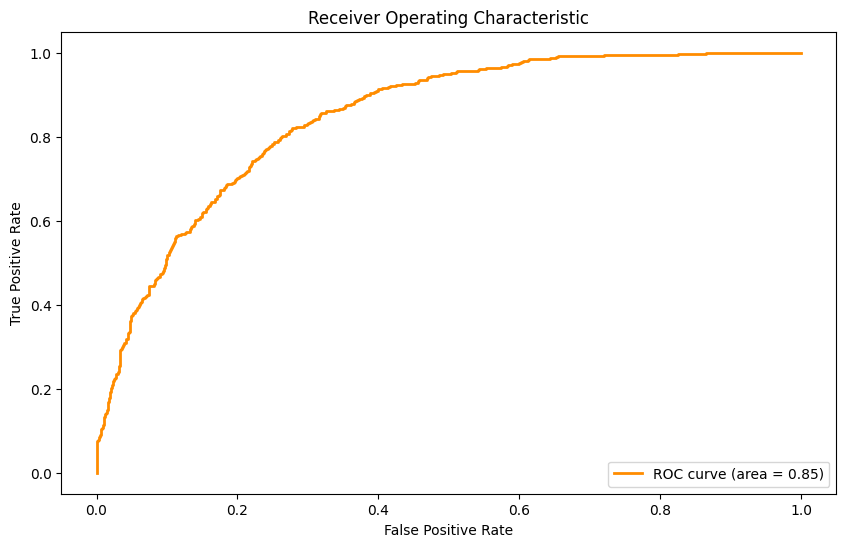

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate the ROC curve and AUC for the model's predictions
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### VI. Precision-Recall Tradeoff

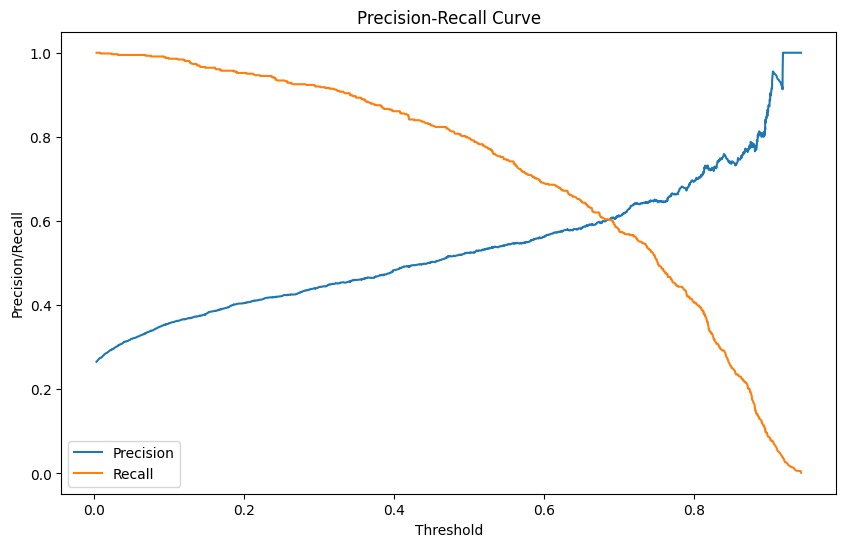

In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculate the precision-recall curve for the model's predictions
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10,6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

The precision-recall curve shows the tradeoff between precision and recall as the classification threshold changes. At lower thresholds, the model identifies more customers as potential churners. This produces higher recall because more actual churners are captured, but it also produces more false positives and therefore lower precision.

As the threshold increases, precision generally improves because the model becomes more selective, but recall decreases because more actual churners are missed. Around a threshold of approximately 0.7, the two metrics are relatively close to one another. At the default threshold of 0.5, recall is substantially higher than precision, meaning the current model is configured to identify more potential churners at the cost of additional false positives.

The appropriate threshold ultimately depends on the business cost of false positives versus false negatives.

## E. Softmax Regression

### I. Softmax Regression Overview

Softmax regression, also called multinomial logistic regression, extends logistic regression to problems with more than two classes. Logistic regression uses the sigmoid function for a binary outcome, while softmax regression uses the softmax function to produce a probability distribution across multiple classes, with the probabilities summing to 1.

Two libraries that can be used to build a softmax regression model are:

- **scikit-learn:** supports multiclass logistic regression through `LogisticRegression`, including the multinomial formulation.
- **TensorFlow:** can implement softmax regression as a neural network with no hidden layers, using a `Dense` output layer with a softmax activation and categorical cross-entropy loss.

### II. Softmax Model Parameters

With 10 features and 4 classes:

- Weights: 10 features × 4 classes = **40 weights**
- Biases: 1 bias × 4 classes = **4 biases**
- Total parameters: 40 + 4 = **44 parameters**

## F. K-Nearest Neighbors (KNN)

### I. Baseline KNN on Unbalanced Data

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train a K-Nearest Neighbors classifier on the unbalanced training data
knn_unbalanced = KNeighborsClassifier(n_neighbors=10)
knn_unbalanced.fit(X_train_unbalanced, y_train_unbalanced)

# Make predictions on the test set using the unbalanced KNN model
y_pred_unbalanced = knn_unbalanced.predict(X_test)
y_proba_unbalanced = knn_unbalanced.predict_proba(X_test)[:, 1]

# Evaluate the performance of the unbalanced KNN model
print(confusion_matrix(y_test, y_pred_unbalanced))
print(classification_report(y_test, y_pred_unbalanced))

[[1375  177]
 [ 322  239]]
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85      1552
         1.0       0.57      0.43      0.49       561

    accuracy                           0.76      2113
   macro avg       0.69      0.66      0.67      2113
weighted avg       0.75      0.76      0.75      2113



### II. KNN with Balanced Training Data

In [ ]:
# Train a K-Nearest Neighbors classifier on the balanced training data
knn_balanced = KNeighborsClassifier(n_neighbors=10)
knn_balanced.fit(X_train, y_train)

# Make predictions on the test set using the balanced KNN model
y_pred_balanced = knn_balanced.predict(X_test)
y_proba_balanced = knn_balanced.predict_proba(X_test)[:, 1]

# Evaluate the performance of the balanced KNN model
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[1086  466]
 [ 159  402]]
              precision    recall  f1-score   support

         0.0       0.87      0.70      0.78      1552
         1.0       0.46      0.72      0.56       561

    accuracy                           0.70      2113
   macro avg       0.67      0.71      0.67      2113
weighted avg       0.76      0.70      0.72      2113



### III. KNN Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create an instance of GridSearchCV
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Use grid search to tune the following hyperparameters
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=['accuracy', 'roc_auc'], refit='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 21),
                         'weights': ['uniform', 'distance']},
             refit='roc_auc', scoring=['accuracy', 'roc_auc'])

### IV. Best KNN Parameters

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}
0.9000380588146756


### V. Tuned KNN Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Train with the best parameters and test
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
y_proba_best = best_knn.predict_proba(X_test)[:, 1]

# Print the confusion matrix, classification report, and ROC AUC
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

[[1173  379]
 [ 228  333]]
              precision    recall  f1-score   support

         0.0       0.84      0.76      0.79      1552
         1.0       0.47      0.59      0.52       561

    accuracy                           0.71      2113
   macro avg       0.65      0.67      0.66      2113
weighted avg       0.74      0.71      0.72      2113

ROC AUC: 0.7561992346141831


### VI. Tuned KNN with PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Create a pipeline with PCA and KNN
pca = PCA(n_components=22)
knn = KNeighborsClassifier(n_neighbors=8, weights='distance', metric='manhattan')
pipeline = Pipeline([('pca', pca), ('knn', knn)])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)
y_pred_pca = pipeline.predict(X_test)
y_proba_pca = pipeline.predict_proba(X_test)[:, 1]

# Print the confusion matrix, classification report, and ROC AUC
print(confusion_matrix(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca))
print("ROC AUC:", roc_auc_score(y_test, y_proba_pca))

[[1132  420]
 [ 215  346]]
              precision    recall  f1-score   support

         0.0       0.84      0.73      0.78      1552
         1.0       0.45      0.62      0.52       561

    accuracy                           0.70      2113
   macro avg       0.65      0.67      0.65      2113
weighted avg       0.74      0.70      0.71      2113

ROC AUC: 0.7451801596927432


### VII. KNN Model Comparison

- **Unbalanced KNN (k=10):** achieved the highest accuracy among the four KNN models (0.76), but recall was relatively low (0.43). Because the training data is imbalanced, the model tends to favor the majority class and misses many actual churners.

- **Rebalanced KNN (k=10):** recall increased to 0.72, meaning the model identified more actual churners. However, accuracy (0.70) and precision (0.46) decreased, indicating an increase in false positives.

- **Tuned KNN:** grid search selected `k=8`, Manhattan distance, and distance weighting. Recall decreased to 0.59 compared with the rebalanced KNN, while ROC AUC was 0.756, indicating reasonable overall discrimination between churners and non-churners.

- **Tuned KNN + PCA (22 components):** produced similar results to the tuned model, with recall of 0.62 and AUC of 0.745. PCA did not substantially improve predictive performance, but it reduced the number of features used by the model.

Overall, balancing the training data substantially improved recall for KNN, while hyperparameter tuning and PCA produced different tradeoffs among recall, precision, accuracy, and AUC.

## G. Naive Bayes

### I. Gaussian Naive Bayes Evaluation

[[1016  536]
 [  85  476]]
              precision    recall  f1-score   support

         0.0       0.92      0.65      0.77      1552
         1.0       0.47      0.85      0.61       561

    accuracy                           0.71      2113
   macro avg       0.70      0.75      0.69      2113
weighted avg       0.80      0.71      0.72      2113



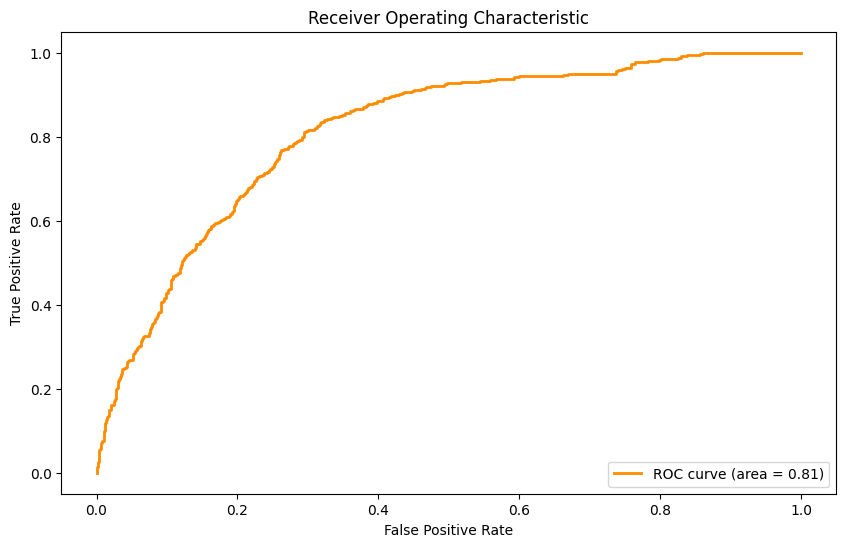

Misclassifications: 621


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Train a GaussianNB model
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_proba_gnb = gnb.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

# Plot the ROC curve and show the AUC
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_test, y_proba_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)

plt.figure(figsize=(10,6))
plt.plot(fpr_gnb, tpr_gnb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_gnb)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications
misclassifications_gnb = sum(y_test != y_pred_gnb)
print("Misclassifications:", misclassifications_gnb)

### II. Categorical Naive Bayes Evaluation

In [ ]:
#from sklearn.naive_bayes import CategoricalNB
#cnb_bad = CategoricalNB()
#cnb_bad.fit(X_train, y_train)  # your scaled/dummy data
#y_pred_bad = cnb_bad.predict(X_test)  # likely throws an error here

# Tried to run code with continous columns - failed because CategoricalNB treats every value in each column as a category index,
# and it expects those indices to be small integers starting at 0 (0, 1, 2, 3...). Since our scaled continuous columns have values like
# 0.234871, 0.891023, etc., CategoricalNB tried to interpret those floats as category, and the math broke because it's trying
# to index into an array that's way too small for what it's receiving.

In [ ]:
# CategoricalNB requires integer-encoded categories rather than scaled floats. Since continuous columns like
# tenure/MonthlyCharges/TotalCharges were previously scaled with MinMaxScaler into float, CategoricalNB treats each unique float
# as its own category, which caused errors in a code above. So we rebuild a non-scaled, integer-only version of the data here.

telco_cat = pd.read_csv("../data/telco_churn.csv")

telco_cat = telco_cat.drop(columns=['customerID', 'SupportTicketID', 'ActiveCountryCode'])

# Clean TotalCharges
telco_cat['TotalCharges'] = pd.to_numeric(telco_cat['TotalCharges'], errors='coerce')
telco_cat['TotalCharges'] = telco_cat['TotalCharges'].fillna(0)

# Encode Education
edu_map = {
    'High School Graduate': 0,
    'Associate Degree': 1,
    "Bachelor's Degree": 2,
    "Master's Degree": 3
}
telco_cat['Education'] = telco_cat['Education'].map(edu_map)
telco_cat['Education'] = telco_cat['Education'].fillna(4)     # 4 = Unknown, instead of -1 (non-negative for CategoricalNB)

# Encode Contract
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
telco_cat['Contract'] = telco_cat['Contract'].map(contract_map)

print(telco_cat.shape)
telco_cat.head()

(7043, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Education,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,0,Yes,Electronic check,29.85,29.85,4.0,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,1,No,Mailed check,56.95,1889.50,4.0,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,0,Yes,Mailed check,53.85,108.15,1.0,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,1,No,Bank transfer (automatic),42.30,1840.75,4.0,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,0,Yes,Electronic check,70.70,151.65,0.0,Yes


[[1094  458]
 [ 108  453]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1552
           1       0.50      0.81      0.62       561

    accuracy                           0.73      2113
   macro avg       0.70      0.76      0.70      2113
weighted avg       0.80      0.73      0.75      2113



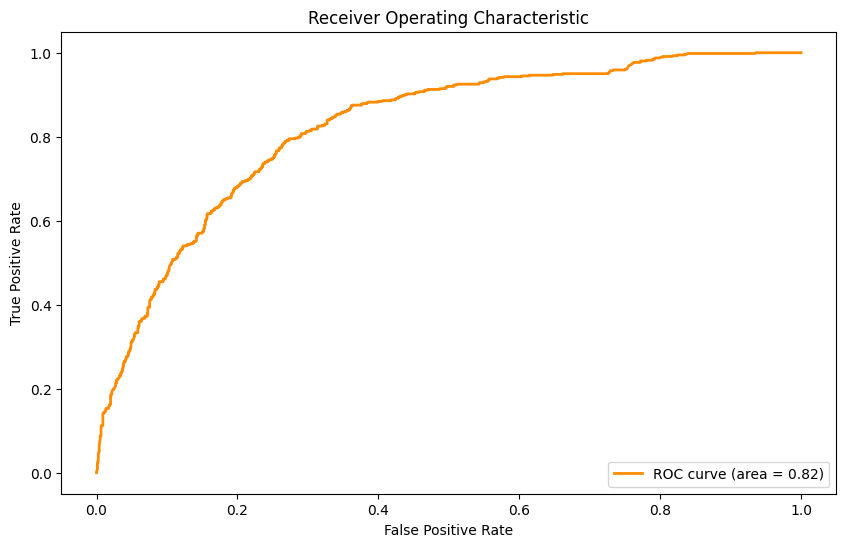

Misclassifications: 566


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB

nominal_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
                'PaymentMethod']

continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Ordinal-encode nominal columns into integer category codes
ord_encoder = OrdinalEncoder()
nominal_encoded = ord_encoder.fit_transform(telco_cat[nominal_cols])

# Bin continuous columns into 4 quantile-based integer buckets
binner = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
continuous_binned = binner.fit_transform(telco_cat[continuous_cols])

# Combine nominal and continous
X_cat = np.hstack([
    nominal_encoded,
    continuous_binned,
    telco_cat[['Contract', 'Education']].values
]).astype(int)

y_cat = telco_cat['Churn'].map({'Yes': 1, 'No': 0}).values

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.30, random_state=0, stratify=y_cat
)

# Train a CategorialNB model
cat_nb = CategoricalNB()
cat_nb.fit(X_train_cat, y_train_cat)
y_pred_cat = cat_nb.predict(X_test_cat)
y_proba_cat = cat_nb.predict_proba(X_test_cat)[:, 1]

# Print the confusion matrix and classification report
print(confusion_matrix(y_test_cat, y_pred_cat))
print(classification_report(y_test_cat, y_pred_cat))

# Plot the ROC curve and show the AUC
fpr_cat, tpr_cat, thresholds_cat = roc_curve(y_test_cat, y_proba_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

plt.figure(figsize=(10,6))
plt.plot(fpr_cat, tpr_cat, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_cat)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications
misclassifications_cat = sum(y_test_cat != y_pred_cat)
print("Misclassifications:", misclassifications_cat)

## H. Support Vector Machine

### I. SVM Hyperparameter Tuning

In [ ]:
from sklearn.svm import SVC

# Create an instance of GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'sigmoid']
}

# Use grid search to tune the following hyperparameters
svc = SVC(probability=True)
grid_search = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
{'C': 100, 'gamma': 1, 'kernel': 'rbf'}
0.8819753416778019


The grid search was limited to the `rbf` and `sigmoid` kernels, excluding `poly`, and used three-fold cross-validation to keep runtime manageable because SVM with `probability=True` is computationally expensive on a dataset of this size.

### II. SVM Evaluation

Best parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best CV accuracy: 0.8819753416778019
[[1380  172]
 [ 340  221]]
              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84      1552
         1.0       0.56      0.39      0.46       561

    accuracy                           0.76      2113
   macro avg       0.68      0.64      0.65      2113
weighted avg       0.74      0.76      0.74      2113



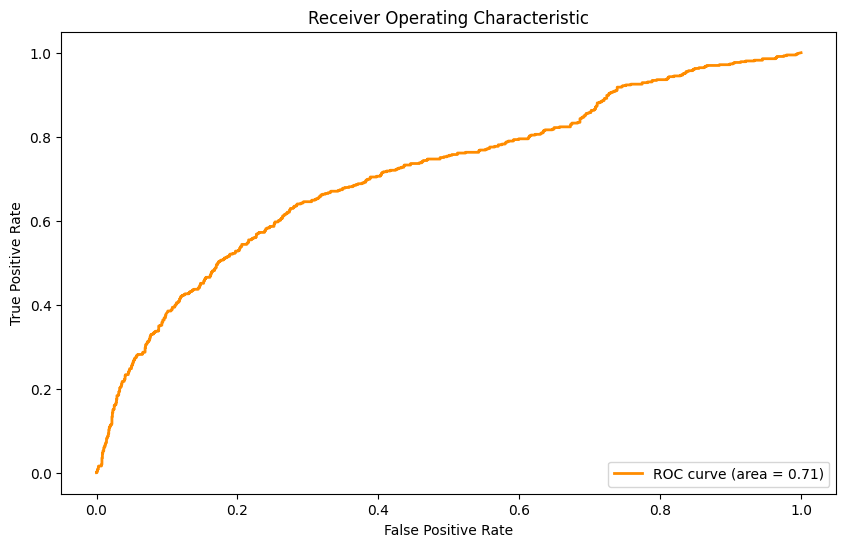

Misclassifications: 512


In [ ]:
# Print best parameters found
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred_svc = best_svc.predict(X_test)
y_proba_svc = best_svc.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

# ROC curve and AUC
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_proba_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)

plt.figure(figsize=(10,6))
plt.plot(fpr_svc, tpr_svc, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_svc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications
misclassifications_svc = sum(y_test != y_pred_svc)
print("Misclassifications:", misclassifications_svc)

## I. Decision Tree

### I. Decision Tree on Unbalanced Training Data

Fitting 3 folds for each of 19 candidates, totalling 57 fits
{'max_depth': 4}
0.7817432110173712
[[1390  162]
 [ 273  288]]
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.86      1552
         1.0       0.64      0.51      0.57       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.72      2113
weighted avg       0.78      0.79      0.79      2113



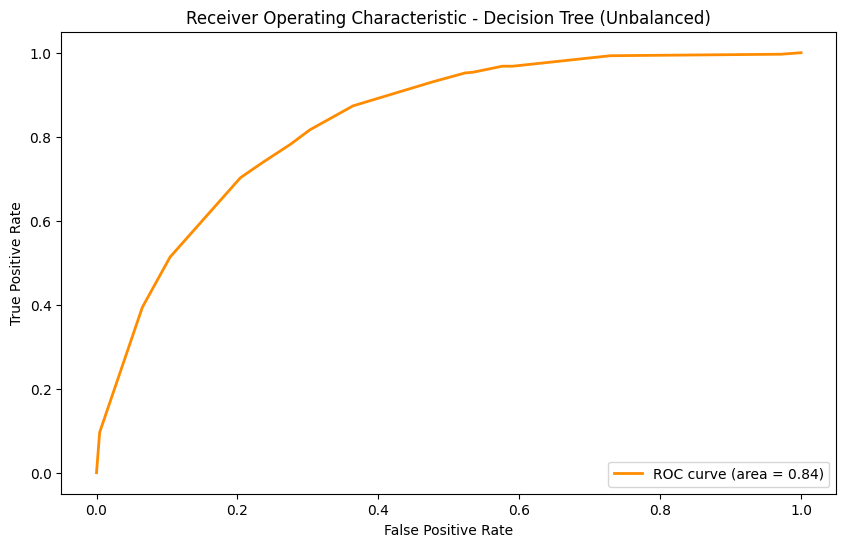

Misclassifications: 435


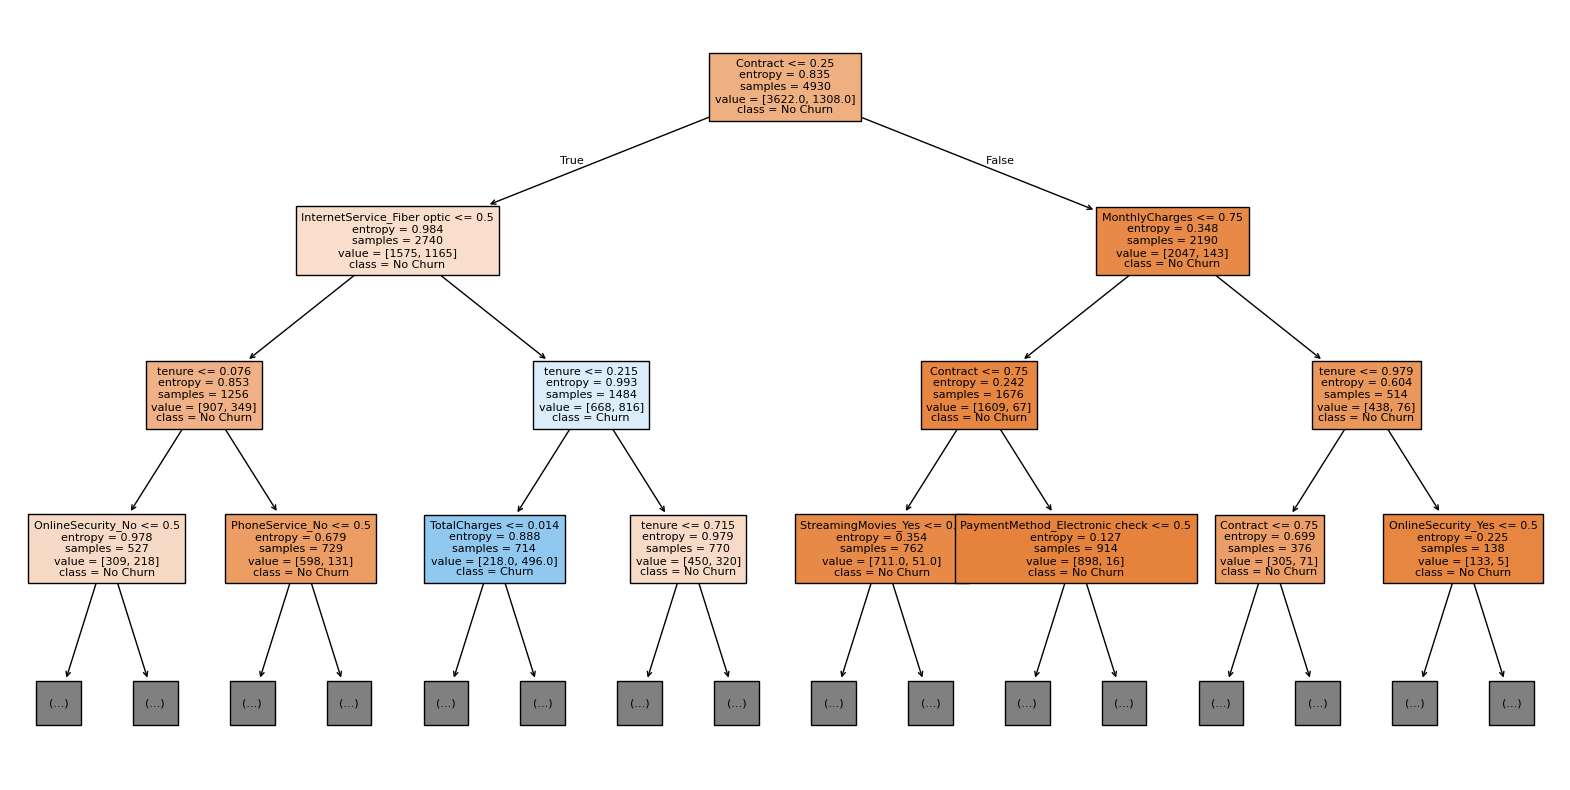

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Define the range of max_depth values to evaluate using grid search
param_grid_dt = {'max_depth': range(2, 21)}

# Initialize a decision tree using entropy as the splitting criterion
dt_unbal = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Set up 3-fold cross-validation to find the best tree depth
grid_search_dt_unbal = GridSearchCV(dt_unbal, param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_dt_unbal.fit(X_train_unbalanced, y_train_unbalanced)

# Display the best max_depth value and best cross-validation score
print(grid_search_dt_unbal.best_params_)
print(grid_search_dt_unbal.best_score_)

# Train the best decision tree model and evaluate it on the test set
best_dt_unbal = grid_search_dt_unbal.best_estimator_
y_pred_dt_unbal = best_dt_unbal.predict(X_test)
y_proba_dt_unbal = best_dt_unbal.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred_dt_unbal))
print(classification_report(y_test, y_pred_dt_unbal))

# Plot the ROC curve and show the AUC
fpr_dt_unbal, tpr_dt_unbal, thresholds_dt_unbal = roc_curve(y_test, y_proba_dt_unbal)
roc_auc_dt_unbal = auc(fpr_dt_unbal, tpr_dt_unbal)

plt.figure(figsize=(10,6))
plt.plot(fpr_dt_unbal, tpr_dt_unbal, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_dt_unbal)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree (Unbalanced)')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications
misclassifications_dt_unbal = sum(y_test != y_pred_dt_unbal)
print("Misclassifications:", misclassifications_dt_unbal)

# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(best_dt_unbal, filled=True, feature_names=X_train.columns, class_names=['No Churn','Churn'], max_depth=3, fontsize=8)
plt.show()

### II. Decision Tree on Balanced Training Data

Fitting 3 folds for each of 19 candidates, totalling 57 fits
{'max_depth': 10}
0.8035658108926361
[[1206  346]
 [ 200  361]]
              precision    recall  f1-score   support

         0.0       0.86      0.78      0.82      1552
         1.0       0.51      0.64      0.57       561

    accuracy                           0.74      2113
   macro avg       0.68      0.71      0.69      2113
weighted avg       0.77      0.74      0.75      2113



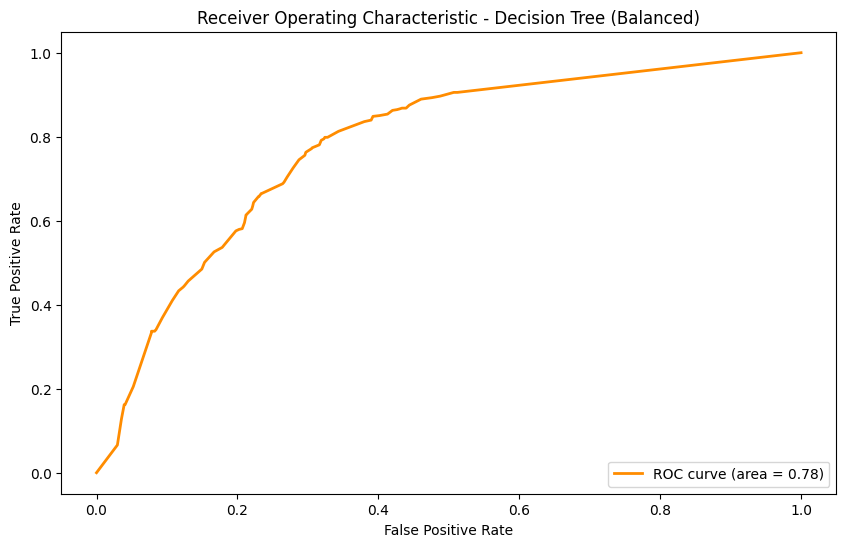

Misclassifications: 546


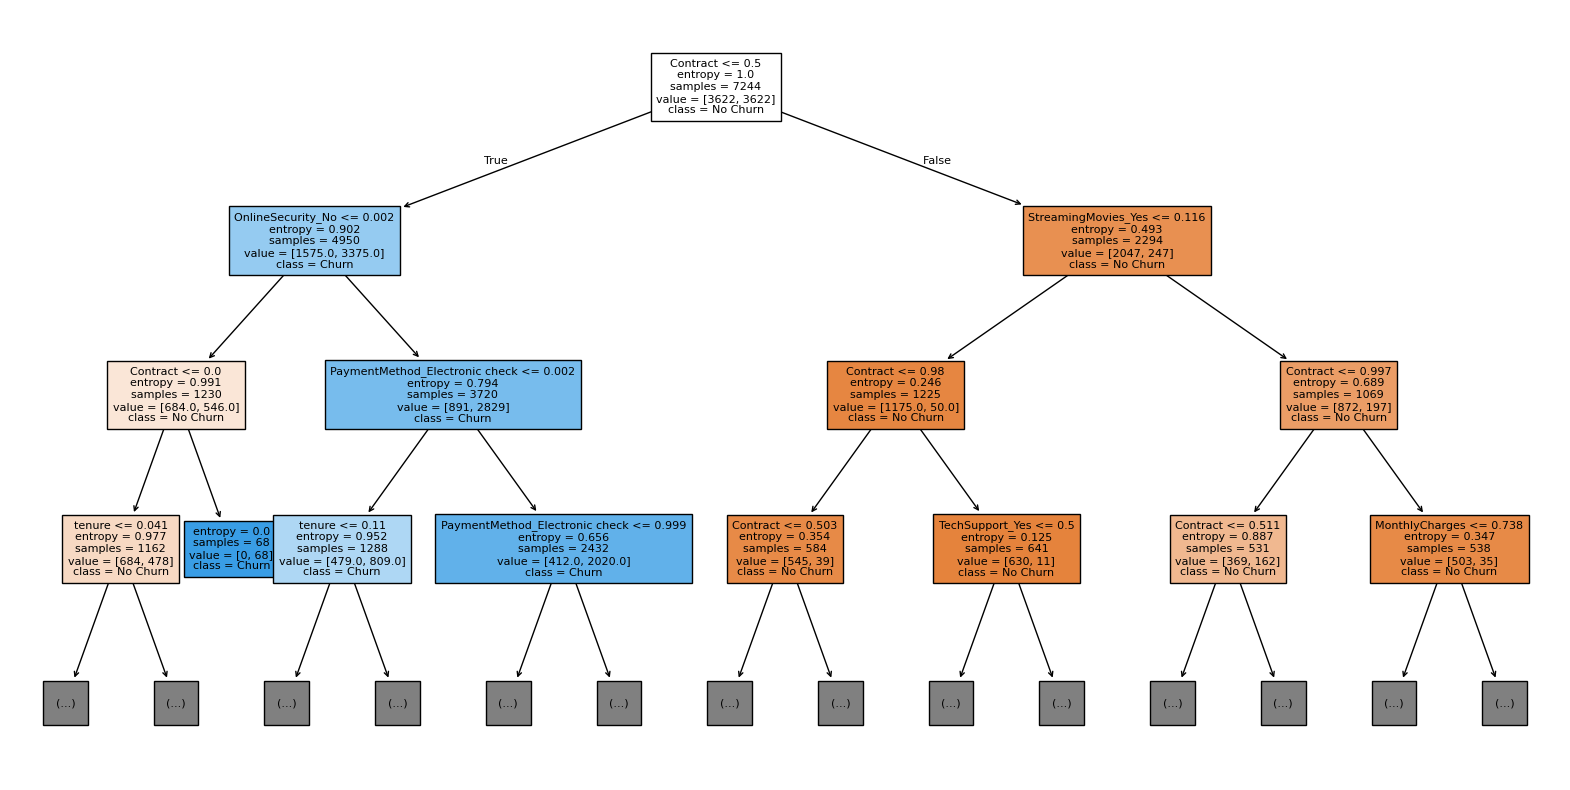

In [ ]:
# Define the range of max_depth values to evaluate using grid search for the balanced dataset
param_grid_dt = {'max_depth': range(2, 21)}

# Initialize a decision tree using entropy as the splitting criterion
dt_bal = DecisionTreeClassifier(criterion='entropy', random_state=0)
grid_search_dt_bal = GridSearchCV(dt_bal, param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_dt_bal.fit(X_train, y_train)

# Display the best max_depth value and best cross-validation score for the balanced dataset
print(grid_search_dt_bal.best_params_)
print(grid_search_dt_bal.best_score_)

# Train the best decision tree model on the balanced dataset and evaluate it on the test set
best_dt_bal = grid_search_dt_bal.best_estimator_
y_pred_dt_bal = best_dt_bal.predict(X_test)
y_proba_dt_bal = best_dt_bal.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report for the balanced dataset
print(confusion_matrix(y_test, y_pred_dt_bal))
print(classification_report(y_test, y_pred_dt_bal))

# Plot the ROC curve and show the AUC for the balanced dataset
fpr_dt_bal, tpr_dt_bal, thresholds_dt_bal = roc_curve(y_test, y_proba_dt_bal)
roc_auc_dt_bal = auc(fpr_dt_bal, tpr_dt_bal)

plt.figure(figsize=(10,6))
plt.plot(fpr_dt_bal, tpr_dt_bal, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_dt_bal)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree (Balanced)')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications for the balanced dataset
misclassifications_dt_bal = sum(y_test != y_pred_dt_bal)
print("Misclassifications:", misclassifications_dt_bal)

# Visualize the decision tree for the balanced dataset
plt.figure(figsize=(20,10))
plot_tree(best_dt_bal, filled=True, feature_names=X_train.columns, class_names=['No Churn','Churn'], max_depth=3, fontsize=8)
plt.show()

### III. Decision Tree Comparison

- The unbalanced tree remained relatively shallow (`max_depth=4`) and achieved an AUC of 0.84 and churn precision of 0.64, with recall of 0.51. The balanced tree required a greater depth (`max_depth=10`) to model the more evenly represented classes. Its churn recall increased to 0.64, while AUC decreased to 0.78, precision decreased to 0.51, and total misclassifications increased from 435 to 546. As with KNN, balancing the data improved the identification of churners but introduced more false positives and reduced some other performance measures.

- In the unbalanced tree, the first split is based on `Contract`, separating month-to-month customers from customers with longer contracts. The tree then uses features such as `InternetService_Fiber optic`, `tenure`, and `OnlineSecurity` in subsequent splits.

- The balanced tree also begins with `Contract`, but later splits rely more heavily on features such as `OnlineSecurity`, `StreamingMovies`, and `PaymentMethod_Electronic_Check`. This suggests that balancing the training data changed which patterns were emphasized by the tree.

## J. Random Forest

### I. Random Forest Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Create an instance of GridSearchCV for Random Forest
rf = RandomForestClassifier(random_state=0)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [10, 50, 100]},
             scoring='accuracy', verbose=2)

### II. Best Random Forest Parameters

In [ ]:
print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)

{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
0.8488468749410357


### III. Random Forest Evaluation

[[1327  225]
 [ 249  312]]
              precision    recall  f1-score   support

         0.0       0.84      0.86      0.85      1552
         1.0       0.58      0.56      0.57       561

    accuracy                           0.78      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.77      0.78      0.77      2113



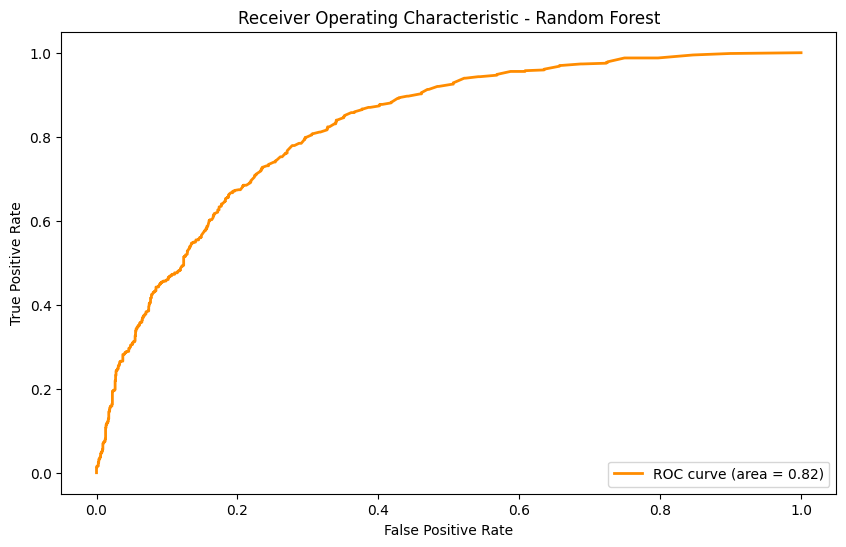

Misclassifications: 474


In [ ]:
# Train the best Random Forest model and evaluate it on the test set
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report for the Random Forest model
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Plot the ROC curve and show the AUC for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10,6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications for the Random Forest model
misclassifications_rf = sum(y_test != y_pred_rf)
print("Misclassifications:", misclassifications_rf)

## K. Boosting Algorithms

### I. AdaBoost Evaluation

Fitting 3 folds for each of 9 candidates, totalling 27 fits
{'learning_rate': 1, 'n_estimators': 50}
0.8009423977796875
[[1184  368]
 [ 136  425]]
              precision    recall  f1-score   support

         0.0       0.90      0.76      0.82      1552
         1.0       0.54      0.76      0.63       561

    accuracy                           0.76      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.76      0.77      2113



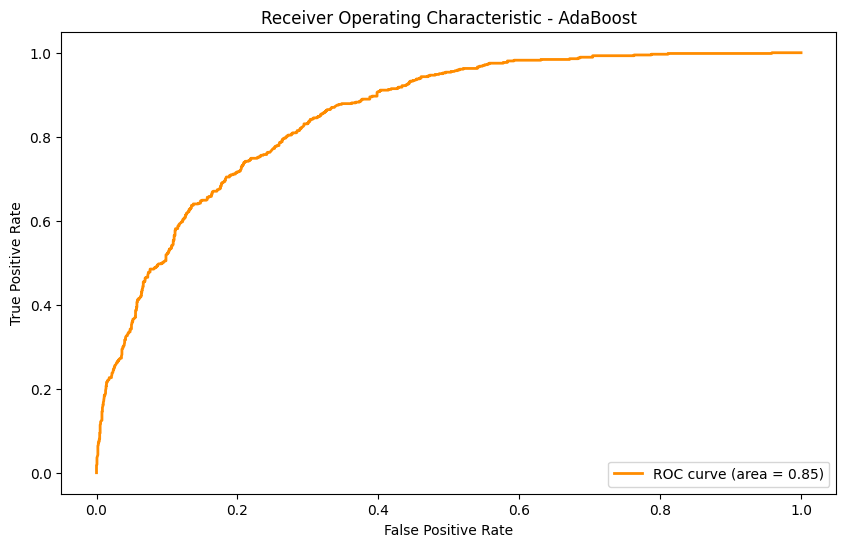

Misclassifications: 504


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Define the hyperparameter grid for AdaBoost
param_grid_ada = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1]
}

# Create an instance of GridSearchCV for AdaBoost
ada = AdaBoostClassifier(random_state=0)
grid_search_ada = GridSearchCV(ada, param_grid_ada, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_ada.fit(X_train, y_train)

# Display the best hyperparameters and best cross-validation score for AdaBoost
print(grid_search_ada.best_params_)
print(grid_search_ada.best_score_)

# Train the best AdaBoost model and evaluate it on the test set
best_ada = grid_search_ada.best_estimator_
y_pred_ada = best_ada.predict(X_test)
y_proba_ada = best_ada.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report for the AdaBoost model
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

# Plot the ROC curve and show the AUC for the AdaBoost model
fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_test, y_proba_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

plt.figure(figsize=(10,6))
plt.plot(fpr_ada, tpr_ada, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_ada)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - AdaBoost')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications for the AdaBoost model
misclassifications_ada = sum(y_test != y_pred_ada)
print("Misclassifications:", misclassifications_ada)

### II. Gradient Boosting Evaluation

Fitting 3 folds for each of 9 candidates, totalling 27 fits
{'learning_rate': 0.1, 'n_estimators': 50}
0.8202700145173399
[[1221  331]
 [ 152  409]]
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.83      1552
         1.0       0.55      0.73      0.63       561

    accuracy                           0.77      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.77      0.78      2113



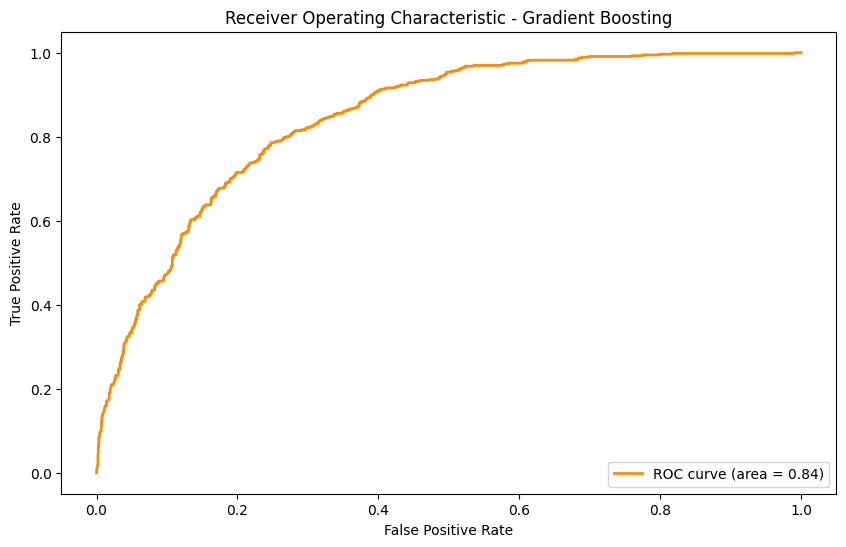

Misclassifications: 483


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define the hyperparameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1]
}

# Create an instance of GridSearchCV for Gradient Boosting
gb = GradientBoostingClassifier(random_state=0)
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_gb.fit(X_train, y_train)

# Display the best hyperparameters and best cross-validation score for Gradient Boosting
print(grid_search_gb.best_params_)
print(grid_search_gb.best_score_)

# Train the best Gradient Boosting model and evaluate it on the test set
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

# Print the confusion matrix and classification report for the Gradient Boosting model
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Plot the ROC curve and show the AUC for the Gradient Boosting model
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(10,6))
plt.plot(fpr_gb, tpr_gb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_gb)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Gradient Boosting')
plt.legend(loc="lower right")
plt.show()

# Count the misclassifications for the Gradient Boosting model
misclassifications_gb = sum(y_test != y_pred_gb)
print("Misclassifications:", misclassifications_gb)

## L. Final Discussion

Looking across the models, no single model performs best on every metric. Because the goal of this project is to identify customers who are likely to churn, recall is particularly important. A false negative means that a customer who actually churns is not identified, while a false positive means that a customer is predicted to churn but does not.

If the primary goal were overall accuracy and minimizing false positives, the unbalanced Decision Tree performed strongly, with 79% accuracy, 0.64 precision, and 435 total misclassifications. However, its recall was 0.51, meaning that it failed to identify approximately half of the customers who actually churned.

GaussianNB achieved the highest recall among the models discussed (0.85), followed by AdaBoost (0.76) and Gradient Boosting (0.73). Logistic Regression and AdaBoost achieved the highest reported AUC of 0.85, followed by the unbalanced Decision Tree and Gradient Boosting at 0.84. AdaBoost achieved an AUC of 0.85 and a recall of 0.76, providing a strong balance between identifying potential churners and limiting false positives.

Using SMOTE generally increased recall by giving the models more examples of the minority churn class, although this could also reduce precision and increase false positives. Therefore, there is a tradeoff between identifying more potential churners and avoiding unnecessary customer interventions.

Based on these results, AdaBoost was selected as the final model because the project prioritizes identifying potential churners over maximizing raw accuracy. The final model choice should depend on the relative business costs of false negatives and false positives.

For future work, the project could evaluate additional boosting methods such as XGBoost or LightGBM, perform a broader hyperparameter search, and investigate additional customer features if they are available. Other resampling techniques, such as Borderline-SMOTE or ADASYN, could also be evaluated to explore different precision-recall tradeoffs.